  # 05 — Statistical Significance Validation of Selected Final Models



  This notebook reruns the strongest selected final models on the same

  repeated stratified cross-validation folds and evaluates whether their

  observed performance differences are statistically significant.



  Compared models:

  - FPLS + linear SVM (J=5)

  - FPLS + logistic regression (J=5)

  - Weighted kNN + standardized Euclidean

  - FPLS + weighted kNN (J=5)



  Main comparison metrics:

  - F1

  - PR-AUC



  Main statistical test:

  - Wilcoxon signed-rank test



  Data:

  - sampled spectra from `xp_sampled_spectra.csv`

  - labels from the same file if available, otherwise from `og_xp.csv`

  - predefined repeated stratified folds from `splits_rskf.json`



  Main exported outputs:

  - significance_fold_metrics.csv

  - significance_summary.csv

  - significance_wilcoxon.csv

  - fig_significance_boxplot_f1.svg

  - fig_significance_boxplot_pr_auc.svg

In [1]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from IPython.display import display

from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


  ## 1. Configuration

In [2]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "05_significance_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = False

SPLIT_FILE = BASE_DIR / "splits_rskf.json"

SAMPLED_CANDIDATES = [
    BASE_DIR / "xp_sampled_spectra.csv",
]

LABEL_CANDIDATES = [
    BASE_DIR / "og_xp.csv",
]

FPLS_J = 5
K_KNN = 5

PAIRWISE_COMPARISONS = [
    ("FPLS + linear SVM (J=5)", "FPLS + logistic regression (J=5)"),
    ("FPLS + linear SVM (J=5)", "Weighted kNN + standardized Euclidean"),
    ("FPLS + linear SVM (J=5)", "FPLS + weighted kNN (J=5)"),
    ("FPLS + logistic regression (J=5)", "Weighted kNN + standardized Euclidean"),
    ("FPLS + logistic regression (J=5)", "FPLS + weighted kNN (J=5)"),
    ("Weighted kNN + standardized Euclidean", "FPLS + weighted kNN (J=5)"),
]


  ## 2. Plot style

In [3]:
COLOR_PRIMARY = "#6193CD"
COLOR_SECONDARY = "#8C8C8C"
COLOR_DARK = "#4A4A4A"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


  ## 3. Helper functions

In [4]:
def find_first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def split_sort_key(k: str):
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return (rep, fold)


def ms(mean, std):
    if pd.isna(mean):
        return np.nan
    return f"{mean:.4f} ± {0.0 if pd.isna(std) else std:.4f}"


def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo, hi = float(np.min(scores_tr)), float(np.max(scores_tr))
    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)
    out = ((scores_te - lo) / (hi - lo)).astype(np.float64)
    return np.clip(out, 0.0, 1.0)


def pick_youden_threshold(y_true: np.ndarray, y_prob: np.ndarray, grid_size: int = 200) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1.0, 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0
        if j > best_j:
            best_j, best_thr = j, float(thr)

    return best_thr


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict:
    out = {"pr_auc": average_precision_score(y_true_te, y_score_te)}

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)
    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out


def summarise_run(df_run: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = [
        "pr_auc",
        "roc_auc",
        "sensitivity",
        "precision",
        "specificity",
        "accuracy",
        "f1",
        "youden_j",
        "youden_threshold",
    ]

    agg = {}
    for m in metric_cols:
        agg[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
        agg[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

    return df_run.groupby(group_cols).agg(**agg).reset_index()


  ## 4. Load sampled spectra, labels, and saved folds

In [5]:
SAMPLED_FILE = find_first_existing(SAMPLED_CANDIDATES)
if SAMPLED_FILE is None:
    raise FileNotFoundError("Could not find sampled spectra file.")

if not SPLIT_FILE.exists():
    raise FileNotFoundError(f"Missing split file: {SPLIT_FILE}")

df_sampled = pd.read_csv(SAMPLED_FILE)
if "source_id" not in df_sampled.columns:
    raise ValueError("Sampled spectra file must contain 'source_id'.")

wl_cols = [c for c in df_sampled.columns if str(c).startswith("wl_")]
if len(wl_cols) == 0:
    raise ValueError("Sampled spectra file must contain wl_* columns.")

if "y" in df_sampled.columns:
    df_m = df_sampled[["source_id", "y"] + wl_cols].copy()
else:
    LABEL_FILE = find_first_existing(LABEL_CANDIDATES)
    if LABEL_FILE is None:
        raise FileNotFoundError("Could not find label file and sampled file has no 'y' column.")
    df_labels = pd.read_csv(LABEL_FILE)
    if "source_id" not in df_labels.columns or "y" not in df_labels.columns:
        raise ValueError("Label file must contain 'source_id' and 'y'.")
    df_m = df_labels[["source_id", "y"]].merge(
        df_sampled[["source_id"] + wl_cols],
        on="source_id",
        how="inner",
        validate="one_to_one",
    )

with open(SPLIT_FILE) as f:
    splits = json.load(f)

split_names = sorted(splits.keys(), key=split_sort_key)
if SMOKE:
    split_names = [k for k in split_names if k.startswith("rep0_")]

F_raw = df_m[wl_cols].to_numpy(dtype=np.float64)
y_all = df_m["y"].to_numpy(dtype=np.int64)

norms = np.linalg.norm(F_raw, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-15)
F_sampled = F_raw / norms

print("Using sampled file:", SAMPLED_FILE.name)
print("Matrix shape:", F_sampled.shape)
print("Number of splits:", len(split_names))
print("Class counts:")
print(pd.Series(y_all).value_counts().sort_index())


Using sampled file: xp_sampled_spectra.csv
Matrix shape: (2815, 343)
Number of splits: 50
Class counts:
0    2257
1     558
Name: count, dtype: int64


  ## 5. Model definitions

In [6]:
@dataclass
class ModelSpec:
    method_label: str
    builder_name: str


MODEL_SPECS = [
    ModelSpec(
        method_label="FPLS + linear SVM (J=5)",
        builder_name="fpls_svm",
    ),
    ModelSpec(
        method_label="FPLS + logistic regression (J=5)",
        builder_name="fpls_lr",
    ),
    ModelSpec(
        method_label="Weighted kNN + standardized Euclidean",
        builder_name="knn_seuclidean",
    ),
    ModelSpec(
        method_label="FPLS + weighted kNN (J=5)",
        builder_name="fpls_knn",
    ),
]


  ## 6. Model-specific helper functions

In [7]:
def fpls_transform(F_tr, y_tr, F_te, J):
    mu = F_tr.mean(axis=0)
    F_tr_c = F_tr - mu
    F_te_c = F_te - mu

    max_allowed_j = min(F_tr_c.shape[0] - 1, F_tr_c.shape[1], J)
    max_allowed_j = max(max_allowed_j, 1)

    pls = PLSRegression(n_components=max_allowed_j)
    pls.fit(F_tr_c, y_tr)

    xi_tr = pls.transform(F_tr_c)
    xi_te = pls.transform(F_te_c)

    return xi_tr, xi_te


def weighted_knn_scores(dists: np.ndarray, y_ref: np.ndarray, k: int = 5) -> np.ndarray:
    idx = np.argsort(dists, axis=1)[:, :k]
    d = np.take_along_axis(dists, idx, axis=1)
    y_nn = y_ref[idx]

    w = 1.0 / np.maximum(d, 1e-12)
    return (w * y_nn).sum(axis=1) / w.sum(axis=1)


def run_fpls_svm(X_tr, y_tr, X_te, J=5):
    xi_tr, xi_te = fpls_transform(X_tr, y_tr, X_te, J)

    scaler = StandardScaler()
    xi_tr_s = scaler.fit_transform(xi_tr)
    xi_te_s = scaler.transform(xi_te)

    clf = SVC(
        C=1.0,
        kernel="linear",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    clf.fit(xi_tr_s, y_tr)

    score_tr = clf.decision_function(xi_tr_s)
    score_te = clf.decision_function(xi_te_s)
    return score_tr, score_te


def run_fpls_lr(X_tr, y_tr, X_te, J=5):
    xi_tr, xi_te = fpls_transform(X_tr, y_tr, X_te, J)

    scaler = StandardScaler()
    xi_tr_s = scaler.fit_transform(xi_tr)
    xi_te_s = scaler.transform(xi_te)

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    clf.fit(xi_tr_s, y_tr)

    score_tr = clf.decision_function(xi_tr_s)
    score_te = clf.decision_function(xi_te_s)
    return score_tr, score_te


def run_knn_seuclidean(X_tr, y_tr, X_te, k=5):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    var_tr = X_tr_s.var(axis=0, ddof=1)
    var_tr = np.where(var_tr < 1e-12, 1e-12, var_tr)

    dists_tr = pairwise_distances(X_tr_s, X_tr_s, metric="seuclidean", V=var_tr)
    dists_te = pairwise_distances(X_te_s, X_tr_s, metric="seuclidean", V=var_tr)

    np.fill_diagonal(dists_tr, np.inf)

    score_tr = weighted_knn_scores(dists_tr, y_tr, k=k)
    score_te = weighted_knn_scores(dists_te, y_tr, k=k)
    return score_tr, score_te


def run_fpls_knn(X_tr, y_tr, X_te, J=5, k=5):
    xi_tr, xi_te = fpls_transform(X_tr, y_tr, X_te, J)

    scaler = StandardScaler()
    xi_tr_s = scaler.fit_transform(xi_tr)
    xi_te_s = scaler.transform(xi_te)

    dists_tr = pairwise_distances(xi_tr_s, xi_tr_s, metric="euclidean")
    dists_te = pairwise_distances(xi_te_s, xi_tr_s, metric="euclidean")

    np.fill_diagonal(dists_tr, np.inf)

    score_tr = weighted_knn_scores(dists_tr, y_tr, k=k)
    score_te = weighted_knn_scores(dists_te, y_tr, k=k)
    return score_tr, score_te


  ## 7. Unified fold runner

In [8]:
def run_model_on_all_folds(spec: ModelSpec) -> pd.DataFrame:
    records = []

    for sname in split_names:
        tr_idx = np.array(splits[sname]["train"], dtype=int)
        te_idx = np.array(splits[sname]["test"], dtype=int)

        X_tr = F_sampled[tr_idx]
        X_te = F_sampled[te_idx]
        y_tr = y_all[tr_idx]
        y_te = y_all[te_idx]

        if spec.builder_name == "fpls_svm":
            score_tr, score_te = run_fpls_svm(X_tr, y_tr, X_te, J=FPLS_J)

        elif spec.builder_name == "fpls_lr":
            score_tr, score_te = run_fpls_lr(X_tr, y_tr, X_te, J=FPLS_J)

        elif spec.builder_name == "knn_seuclidean":
            score_tr, score_te = run_knn_seuclidean(X_tr, y_tr, X_te, k=K_KNN)

        elif spec.builder_name == "fpls_knn":
            score_tr, score_te = run_fpls_knn(X_tr, y_tr, X_te, J=FPLS_J, k=K_KNN)

        else:
            raise ValueError(f"Unknown builder: {spec.builder_name}")

        met = fold_metrics(y_te, score_te, y_tr, score_tr)

        records.append({
            "split": sname,
            "method": spec.method_label,
            **met,
        })

    return pd.DataFrame(records)


  ## 8. Run all selected models

In [9]:
all_runs = []

for spec in MODEL_SPECS:
    print(f"Running: {spec.method_label}")
    df_model = run_model_on_all_folds(spec)
    all_runs.append(df_model)

df_fold = pd.concat(all_runs, ignore_index=True)

print("\nFold-level results preview:")
display(df_fold.head())


Running: FPLS + linear SVM (J=5)
Running: FPLS + logistic regression (J=5)
Running: Weighted kNN + standardized Euclidean
Running: FPLS + weighted kNN (J=5)

Fold-level results preview:


,split,method,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,f1,youden_j
0,rep0_fold0,FPLS + linear SVM (J=5),0.923526,0.953520,0.216080,0.882883,0.852174,0.962389,0.946714,0.867257,0.845272
1,rep0_fold1,FPLS + linear SVM (J=5),0.813384,0.897194,0.180905,0.765766,0.758929,0.940265,0.905861,0.762332,0.706031
2,rep0_fold2,FPLS + linear SVM (J=5),0.856472,0.925701,0.195980,0.830357,0.830357,0.957871,0.932504,0.830357,0.788229
3,rep0_fold3,FPLS + linear SVM (J=5),0.895071,0.946270,0.190955,0.839286,0.758065,0.933481,0.914742,0.796610,0.772767
4,rep0_fold4,FPLS + linear SVM (J=5),0.831098,0.926631,0.155779,0.821429,0.779661,0.942350,0.918295,0.800000,0.763779


  ## 9. Summary table

In [10]:
df_summary = summarise_run(df_fold, ["method"])

df_summary = df_summary.sort_values(
    ["f1_mean", "pr_auc_mean"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

print("\n=== SUMMARY ===")
display(
    df_summary[
        ["method", "f1_mean", "pr_auc_mean", "roc_auc_mean", "youden_j_mean"]
    ]
)



=== SUMMARY ===


,method,f1_mean,pr_auc_mean,roc_auc_mean,youden_j_mean
0,FPLS + linear SVM (J=5),0.808243,0.865758,0.930481,0.774222
1,FPLS + logistic regression (J=5),0.807004,0.869791,0.931930,0.774651
2,FPLS + weighted kNN (J=5),0.800105,0.821988,0.897409,0.729855
3,Weighted kNN + standardized Euclidean,0.682221,0.739134,0.877118,0.635985


  ## 10. Paired Wilcoxon tests

In [11]:
wilcoxon_rows = []

for method_a, method_b in PAIRWISE_COMPARISONS:
    df_a = df_fold[df_fold["method"] == method_a].sort_values("split")
    df_b = df_fold[df_fold["method"] == method_b].sort_values("split")

    common_splits = sorted(set(df_a["split"]).intersection(set(df_b["split"])))
    df_a = df_a[df_a["split"].isin(common_splits)].sort_values("split")
    df_b = df_b[df_b["split"].isin(common_splits)].sort_values("split")

    if len(df_a) == 0 or len(df_b) == 0:
        continue

    for metric in ["f1", "pr_auc"]:
        x = df_a[metric].to_numpy(dtype=float)
        y = df_b[metric].to_numpy(dtype=float)

        try:
            stat, pval = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
        except ValueError:
            stat, pval = np.nan, np.nan

        wilcoxon_rows.append({
            "method_a": method_a,
            "method_b": method_b,
            "metric": metric,
            "n_pairs": len(x),
            "mean_a": np.mean(x),
            "mean_b": np.mean(y),
            "mean_diff_a_minus_b": np.mean(x - y),
            "wilcoxon_stat": stat,
            "p_value": pval,
            "significant_0_05": bool(pval < 0.05) if not pd.isna(pval) else False,
        })

df_wilcoxon = pd.DataFrame(wilcoxon_rows)

print("\n=== WILCOXON RESULTS ===")
display(df_wilcoxon)



=== WILCOXON RESULTS ===


,method_a,method_b,metric,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value,significant_0_05
0,FPLS + linear SVM (J=5),FPLS + logistic regression (J=5),f1,50,0.808243,0.807004,0.001239,606.0,7.667327e-01,False
1,FPLS + linear SVM (J=5),FPLS + logistic regression (J=5),pr_auc,50,0.865758,0.869791,-0.004032,3.0,8.881784e-15,True
2,FPLS + linear SVM (J=5),Weighted kNN + standardized Euclidean,f1,50,0.808243,0.682221,0.126022,0.0,1.776357e-15,True
3,FPLS + linear SVM (J=5),Weighted kNN + standardized Euclidean,pr_auc,50,0.865758,0.739134,0.126624,0.0,1.776357e-15,True
4,FPLS + linear SVM (J=5),FPLS + weighted kNN (J=5),f1,50,0.808243,0.800105,0.008138,434.0,4.944641e-02,True
5,FPLS + linear SVM (J=5),FPLS + weighted kNN (J=5),pr_auc,50,0.865758,0.821988,0.043770,0.0,1.776357e-15,True
6,FPLS + logistic regression (J=5),Weighted kNN + standardized Euclidean,f1,50,0.807004,0.682221,0.124783,0.0,1.776357e-15,True
7,FPLS + logistic regression (J=5),Weighted kNN + standardized Euclidean,pr_auc,50,0.869791,0.739134,0.130657,0.0,1.776357e-15,True
8,FPLS + logistic regression (J=5),FPLS + weighted kNN (J=5),f1,50,0.807004,0.800105,0.006899,481.0,1.329606e-01,False
9,FPLS + logistic regression (J=5),FPLS + weighted kNN (J=5),pr_auc,50,0.869791,0.821988,0.047802,0.0,1.776357e-15,True


  ## 11. Simple comparison plots

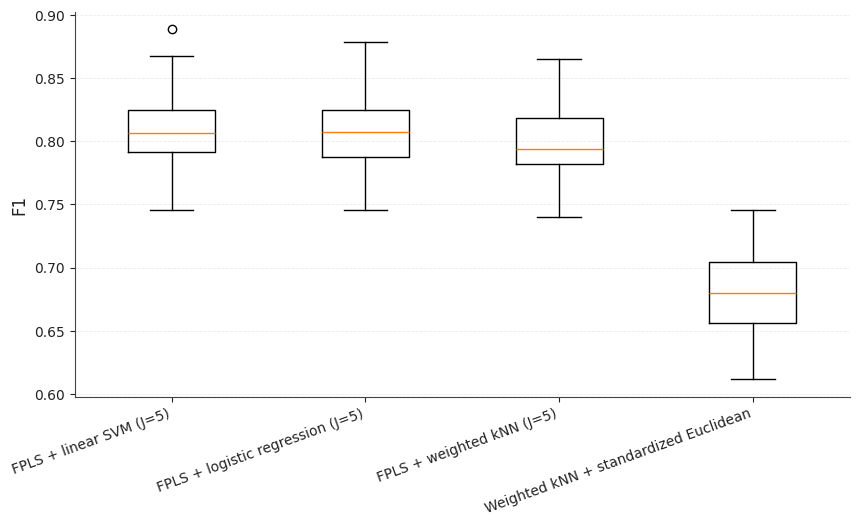

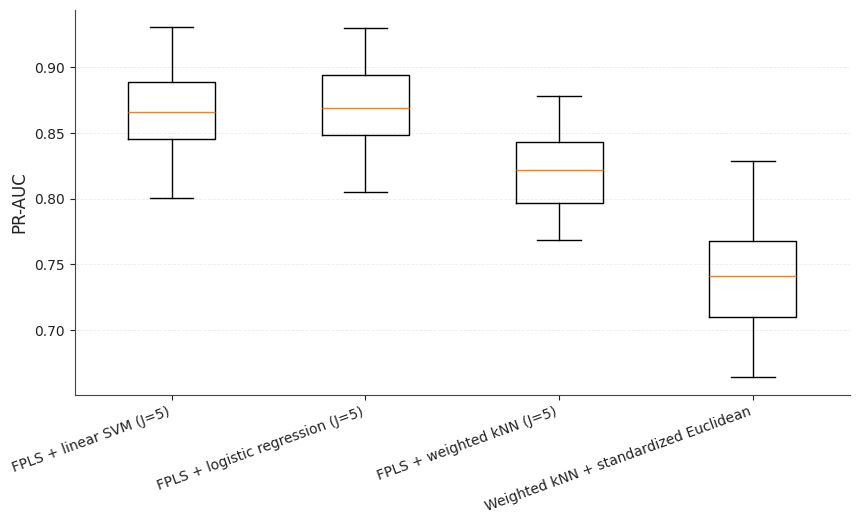

In [12]:
plot_order = df_summary["method"].tolist()

# F1 boxplot
fig, ax = plt.subplots(figsize=(10, 5))
data_f1 = [df_fold.loc[df_fold["method"] == m, "f1"].to_numpy() for m in plot_order]
ax.boxplot(data_f1, labels=plot_order, vert=True)
ax.set_xticklabels(plot_order, rotation=20, ha="right")
ax.set_ylabel("F1")
apply_clean_axes(ax, add_grid=True, grid_axis="y")
plt.show()

# PR-AUC boxplot
fig, ax = plt.subplots(figsize=(10, 5))
data_pr = [df_fold.loc[df_fold["method"] == m, "pr_auc"].to_numpy() for m in plot_order]
ax.boxplot(data_pr, labels=plot_order, vert=True)
ax.set_xticklabels(plot_order, rotation=20, ha="right")
ax.set_ylabel("PR-AUC")
apply_clean_axes(ax, add_grid=True, grid_axis="y")
plt.show()


  ## 12. Save outputs

In [13]:
fold_path = OUT_DIR / "significance_fold_metrics.csv"
summary_path = OUT_DIR / "significance_summary.csv"
wilcoxon_path = OUT_DIR / "significance_wilcoxon.csv"

df_fold.to_csv(fold_path, index=False)
df_summary.to_csv(summary_path, index=False)
df_wilcoxon.to_csv(wilcoxon_path, index=False)

print("Saved main CSV outputs to:", OUT_DIR)


Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\05_significance_validation


  ## 13. Save figures

In [14]:
# F1 boxplot
fig, ax = plt.subplots(figsize=(10, 5))
data_f1 = [df_fold.loc[df_fold["method"] == m, "f1"].to_numpy() for m in plot_order]
ax.boxplot(data_f1, labels=plot_order, vert=True)
ax.set_xticklabels(plot_order, rotation=20, ha="right")
ax.set_ylabel("F1")
apply_clean_axes(ax, add_grid=True, grid_axis="y")
save_fig(OUT_DIR / "fig_significance_boxplot_f1.svg")

# PR-AUC boxplot
fig, ax = plt.subplots(figsize=(10, 5))
data_pr = [df_fold.loc[df_fold["method"] == m, "pr_auc"].to_numpy() for m in plot_order]
ax.boxplot(data_pr, labels=plot_order, vert=True)
ax.set_xticklabels(plot_order, rotation=20, ha="right")
ax.set_ylabel("PR-AUC")
apply_clean_axes(ax, add_grid=True, grid_axis="y")
save_fig(OUT_DIR / "fig_significance_boxplot_pr_auc.svg")

print("Saved figure outputs to:", OUT_DIR)


Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\05_significance_validation


  ## 14. Final quick view

In [15]:
pretty_summary = pd.DataFrame({
    "Method": df_summary["method"],
    "PR-AUC": [ms(m, s) for m, s in zip(df_summary["pr_auc_mean"], df_summary["pr_auc_std"])],
    "ROC-AUC": [ms(m, s) for m, s in zip(df_summary["roc_auc_mean"], df_summary["roc_auc_std"])],
    "F1": [ms(m, s) for m, s in zip(df_summary["f1_mean"], df_summary["f1_std"])],
})

display(pretty_summary)
display(df_wilcoxon)

,Method,PR-AUC,ROC-AUC,F1
0,FPLS + linear SVM (J=5),0.8658 ± 0.0309,0.9305 ± 0.0149,0.8082 ± 0.0295
1,FPLS + logistic regression (J=5),0.8698 ± 0.0301,0.9319 ± 0.0145,0.8070 ± 0.0289
2,FPLS + weighted kNN (J=5),0.8220 ± 0.0307,0.8974 ± 0.0164,0.8001 ± 0.0300
3,Weighted kNN + standardized Euclidean,0.7391 ± 0.0391,0.8771 ± 0.0186,0.6822 ± 0.0331


,method_a,method_b,metric,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value,significant_0_05
0,FPLS + linear SVM (J=5),FPLS + logistic regression (J=5),f1,50,0.808243,0.807004,0.001239,606.0,7.667327e-01,False
1,FPLS + linear SVM (J=5),FPLS + logistic regression (J=5),pr_auc,50,0.865758,0.869791,-0.004032,3.0,8.881784e-15,True
2,FPLS + linear SVM (J=5),Weighted kNN + standardized Euclidean,f1,50,0.808243,0.682221,0.126022,0.0,1.776357e-15,True
3,FPLS + linear SVM (J=5),Weighted kNN + standardized Euclidean,pr_auc,50,0.865758,0.739134,0.126624,0.0,1.776357e-15,True
4,FPLS + linear SVM (J=5),FPLS + weighted kNN (J=5),f1,50,0.808243,0.800105,0.008138,434.0,4.944641e-02,True
5,FPLS + linear SVM (J=5),FPLS + weighted kNN (J=5),pr_auc,50,0.865758,0.821988,0.043770,0.0,1.776357e-15,True
6,FPLS + logistic regression (J=5),Weighted kNN + standardized Euclidean,f1,50,0.807004,0.682221,0.124783,0.0,1.776357e-15,True
7,FPLS + logistic regression (J=5),Weighted kNN + standardized Euclidean,pr_auc,50,0.869791,0.739134,0.130657,0.0,1.776357e-15,True
8,FPLS + logistic regression (J=5),FPLS + weighted kNN (J=5),f1,50,0.807004,0.800105,0.006899,481.0,1.329606e-01,False
9,FPLS + logistic regression (J=5),FPLS + weighted kNN (J=5),pr_auc,50,0.869791,0.821988,0.047802,0.0,1.776357e-15,True
